# **Strategic E-commerce Analytic**

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the data
df1 = pd.read_csv('/content/campaigns.csv')
df2 = pd.read_csv('/content/customers.csv')
df3 = pd.read_csv('/content/events.csv')
df4 = pd.read_csv('/content/products.csv')
df5 = pd.read_csv('/content/transactions.csv')

In [11]:
# summary of the datas
print('='*50)
print('-'*40)
print('information of the data1')
print('- campaigns data')
print('head of the data :',df1.head())
print('shape of the data :',df1.shape)
print('info of the data :',df1.info())
print('columns of the data:',df1.columns )

print('='*50)
print('-'*40)
print('information of the data 2')
print('- campaigns data')
print('head of the data :',df2.head())
print('shape of the data :',df2.shape)
print('info of the data :',df2.info())
print('columns of the data:',df2.columns)

print('='*50)
print('-'*40)
print('information of the data 3')
print('- campaigns data')
print('head of the data :',df3.head())
print('shape of the data :',df3.shape)
print('info of the data :',df3.info())
print('columns of the data:',df3.columns )

print('='*50)
print('-'*40)
print('information of the data 4')
print('- campaigns data')
print('head of the data :',df4.head())
print('shape of the data :',df4.shape)
print('info of the data :',df4.info())
print('columns of the data:',df4.columns )

----------------------------------------
information of the data1
- campaigns data
head of the data :    campaign_id      channel     objective start_date   end_date  \
0            1  Paid Search    Cross-sell 2021-10-25 2021-11-26   
1            2        Email     Retention 2021-10-24 2021-12-24   
2            3        Email  Reactivation 2023-10-08 2023-11-30   
3            4      Display  Reactivation 2022-07-25 2022-10-07   
4            5       Social   Acquisition 2022-07-09 2022-09-29   

  target_segment  expected_uplift  
0   Deal Seekers            0.022  
1   Deal Seekers            0.116  
2     Churn Risk            0.100  
3   Deal Seekers            0.111  
4  New Customers            0.144  
shape of the data : (50, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   campaign_id      50 non-null     int64

In [13]:
import warnings
warnings.filterwarnings('ignore')

# --- Data Cleaning and Visualization for df1 (campaigns) ---
print("\n--- Cleaning and Visualizing df1 (campaigns) ---")

# 1. Data Cleaning df1
print("\nChecking for missing values in df1:")
print(df1.isnull().sum())
print("\nChecking for duplicate rows in df1:")
print(df1.duplicated().sum())

df1['start_date'] = pd.to_datetime(df1['start_date'])
df1['end_date'] = pd.to_datetime(df1['end_date'])
print("Converted 'start_date' and 'end_date' to datetime objects in df1.")


--- Cleaning and Visualizing df1 (campaigns) ---

Checking for missing values in df1:
campaign_id        0
channel            0
objective          0
start_date         0
end_date           0
target_segment     0
expected_uplift    0
dtype: int64

Checking for duplicate rows in df1:
0
Converted 'start_date' and 'end_date' to datetime objects in df1.


Text(0.5, 1.0, 'Distribution of Campaign Channels')

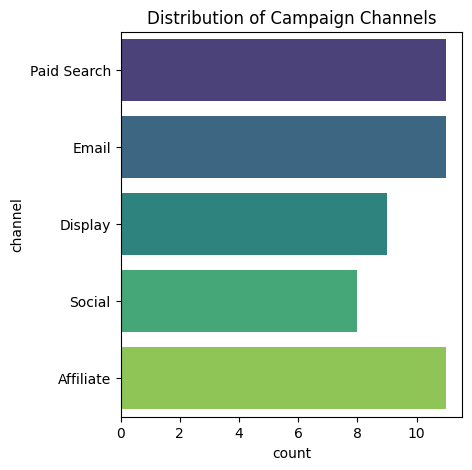

In [14]:
# 2. Visualizations for df1
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.countplot(y='channel', data=df1, palette='viridis')
plt.title('Distribution of Campaign Channels')

Text(0.5, 1.0, 'Distribution of Campaign Objectives')

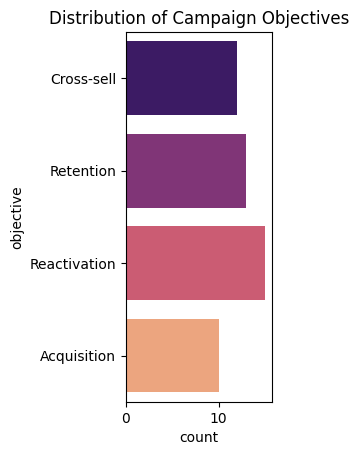

In [15]:
plt.subplot(1, 3, 2)
sns.countplot(y='objective', data=df1, palette='magma')
plt.title('Distribution of Campaign Objectives')


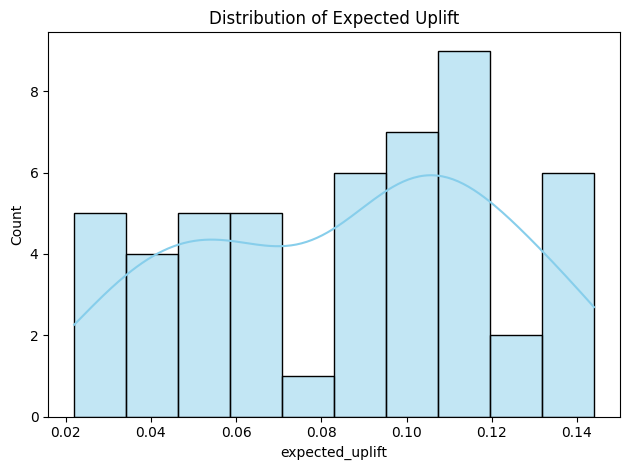

In [21]:
sns.histplot(df1['expected_uplift'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Expected Uplift')
plt.tight_layout()
plt.show()

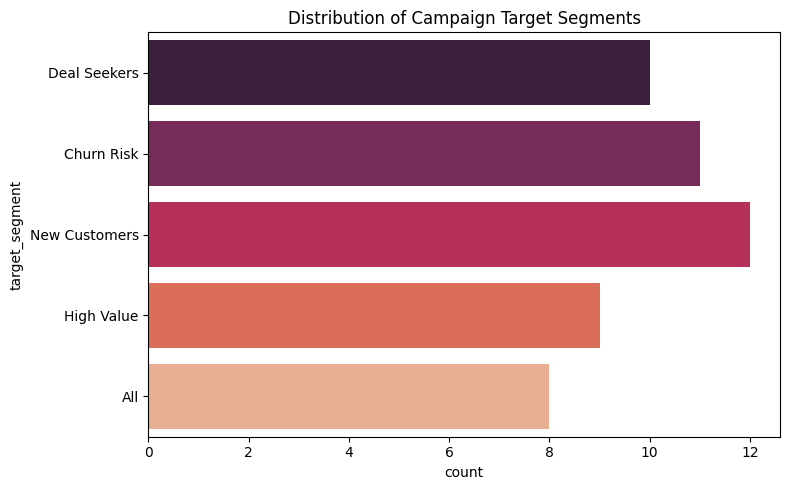

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(y='target_segment', data=df1, palette='rocket')
plt.title('Distribution of Campaign Target Segments')
plt.tight_layout()
plt.show()

In [23]:
# --- Data Cleaning and Visualization for df2 (customers) ---
print("\n--- Cleaning and Visualizing df2 (customers) ---")

# 1. Data Cleaning df2
print("\nChecking for missing values in df2:")
print(df2.isnull().sum())
print("\nChecking for duplicate rows in df2:")
print(df2.duplicated().sum())

df2['signup_date'] = pd.to_datetime(df2['signup_date'])
print("Converted 'signup_date' to datetime objects in df2.")


--- Cleaning and Visualizing df2 (customers) ---

Checking for missing values in df2:
customer_id            0
signup_date            0
country                0
age                    0
gender                 0
loyalty_tier           0
acquisition_channel    0
signup_year_month      0
dtype: int64

Checking for duplicate rows in df2:
0
Converted 'signup_date' to datetime objects in df2.


Text(0.5, 1.0, 'Distribution of Customer Loyalty Tier')

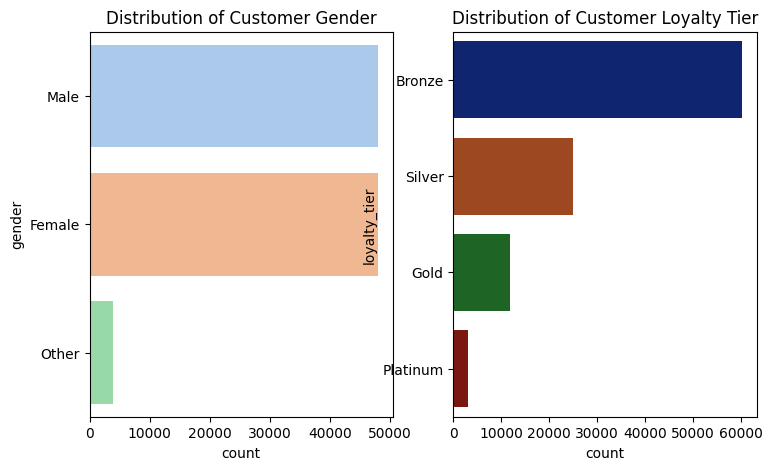

In [24]:
# 2. Visualizations for df2
plt.figure(figsize=(18, 5))
plt.subplot(1, 4, 1)
sns.countplot(y='gender', data=df2, palette='pastel')
plt.title('Distribution of Customer Gender')

plt.subplot(1, 4, 2)
sns.countplot(y='loyalty_tier', data=df2, palette='dark')
plt.title('Distribution of Customer Loyalty Tier')


Text(0.5, 1.0, 'Distribution of Customer Age')

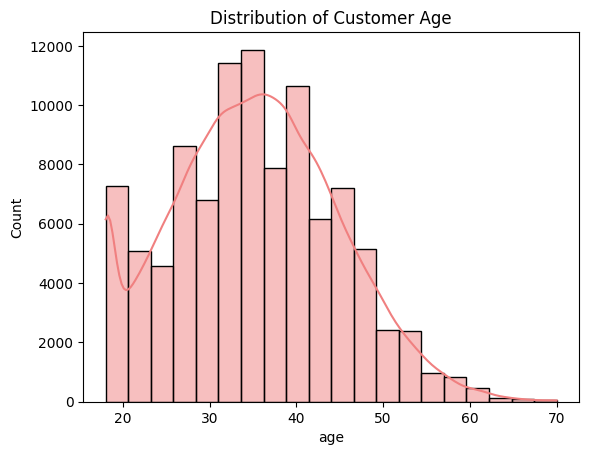

In [27]:
sns.histplot(df2['age'], bins=20, kde=True, color='lightcoral')
plt.title('Distribution of Customer Age')

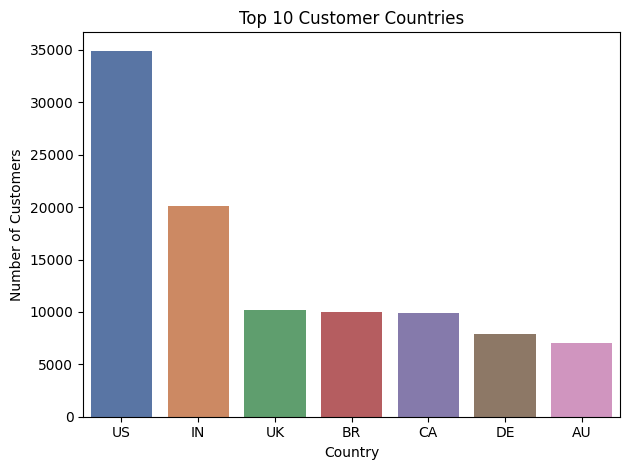

In [29]:
top_countries = df2['country'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='deep')
plt.title('Top 10 Customer Countries')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

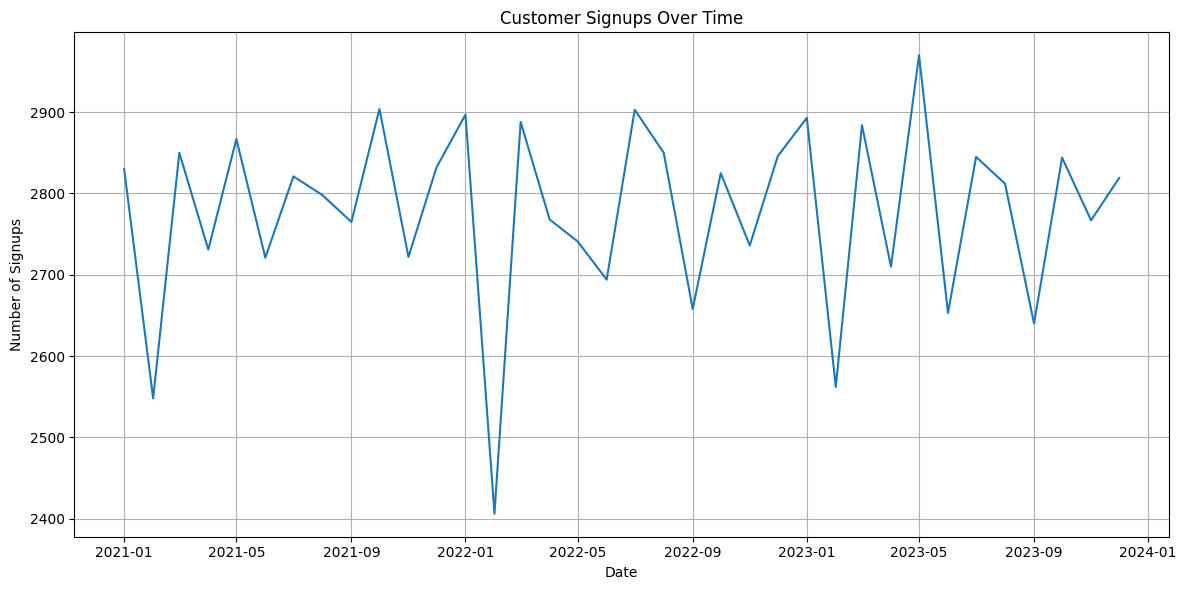

In [30]:
# Customer signup trend over time
plt.figure(figsize=(12, 6))
df2['signup_year_month'] = df2['signup_date'].dt.to_period('M')
signups_over_time = df2['signup_year_month'].value_counts().sort_index()
signups_over_time.index = signups_over_time.index.to_timestamp()
sns.lineplot(x=signups_over_time.index, y=signups_over_time.values)
plt.title('Customer Signups Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Signups')
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
# --- Data Cleaning and Visualization for df3 (events) ---
print("\n--- Cleaning and Visualizing df3 (events) ---")

# 1. Data Cleaning df3
print("\nChecking for missing values in df3:")
print(df3.isnull().sum())
print("\nChecking for duplicate rows in df3:")
print(df3.duplicated().sum())

df3['timestamp'] = pd.to_datetime(df3['timestamp'])
print("Converted 'timestamp' to datetime objects in df3.")


--- Cleaning and Visualizing df3 (events) ---

Checking for missing values in df3:
event_id                     0
timestamp                    0
customer_id                  0
session_id                   0
event_type                   0
product_id              200371
device_type              40300
traffic_source               0
campaign_id                  0
page_category                0
session_duration_sec         0
experiment_group             0
event_date                   0
dtype: int64

Checking for duplicate rows in df3:
0
Converted 'timestamp' to datetime objects in df3.


Text(0.5, 1.0, 'Distribution of Device Types')

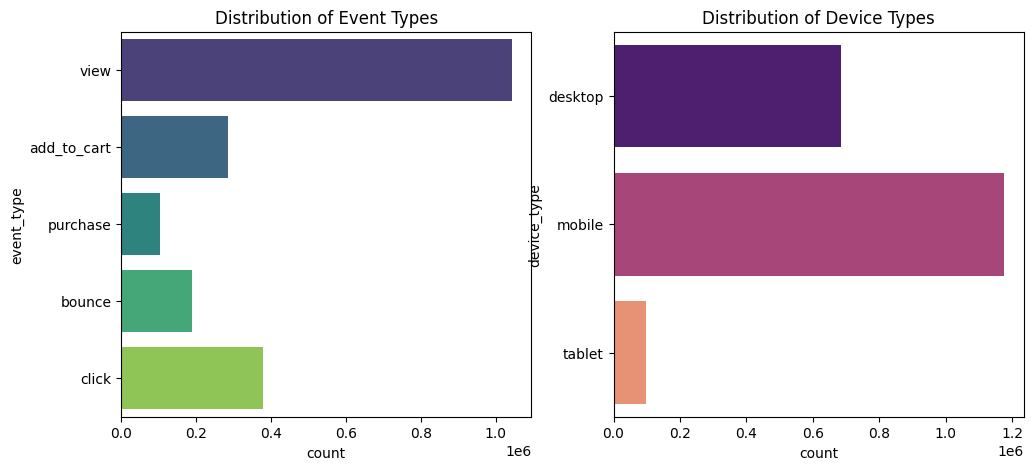

In [32]:
# 2. Visualizations for df3
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.countplot(y='event_type', data=df3, palette='viridis')
plt.title('Distribution of Event Types')

plt.subplot(1, 3, 2)
sns.countplot(y='device_type', data=df3, palette='magma')
plt.title('Distribution of Device Types')


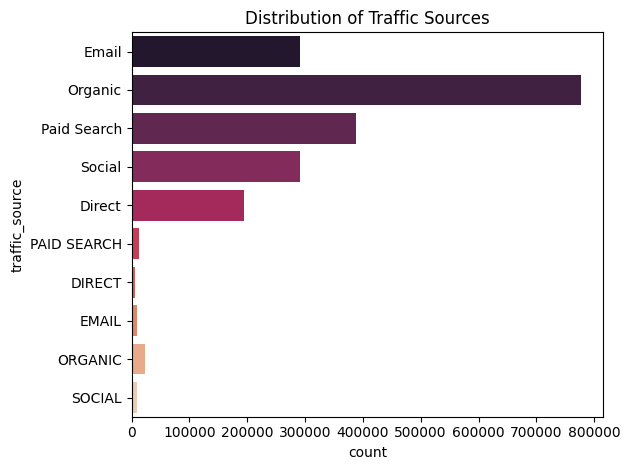

In [35]:
sns.countplot(y='traffic_source', data=df3, palette='rocket')
plt.title('Distribution of Traffic Sources')
plt.tight_layout()
plt.show()

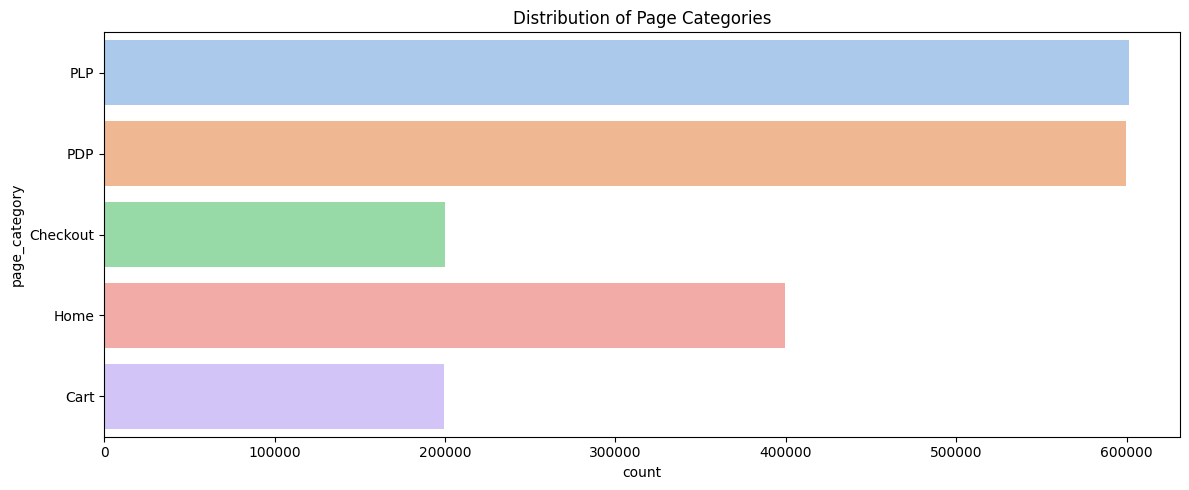

In [34]:
plt.figure(figsize=(12, 5))
sns.countplot(y='page_category', data=df3, palette='pastel')
plt.title('Distribution of Page Categories')
plt.tight_layout()
plt.show()

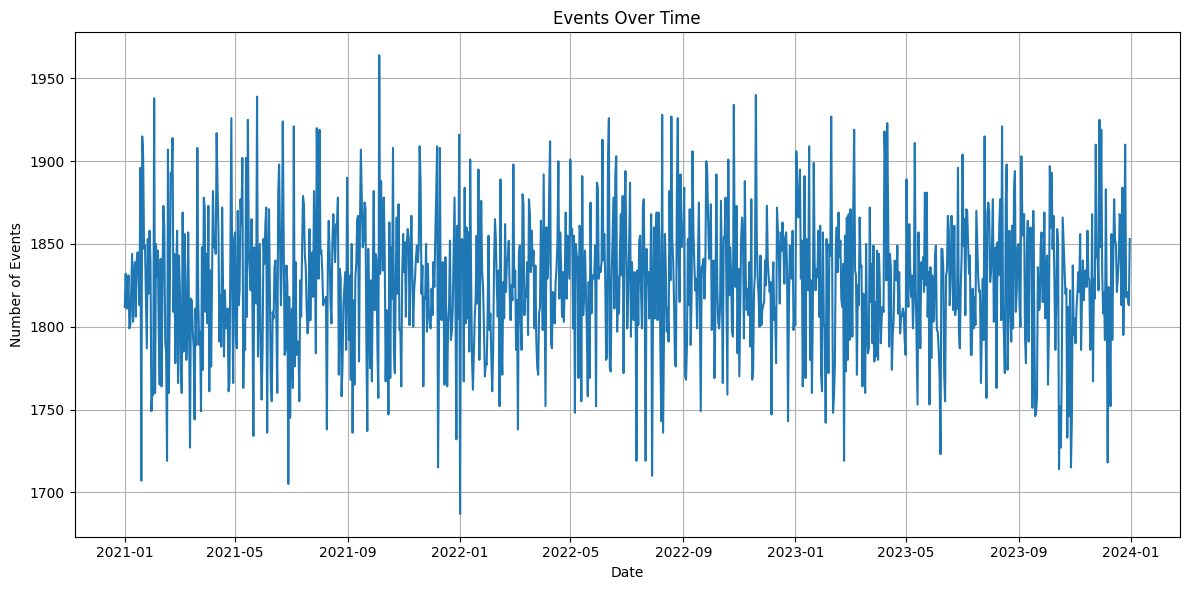

In [36]:
plt.figure(figsize=(12, 6))
df3['event_date'] = df3['timestamp'].dt.to_period('D')
events_over_time = df3['event_date'].value_counts().sort_index()
events_over_time.index = events_over_time.index.to_timestamp()
sns.lineplot(x=events_over_time.index, y=events_over_time.values)
plt.title('Events Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
# --- Data Cleaning and Visualization for df4 (products) ---
print("\n--- Cleaning and Visualizing df4 (products) ---")

# 1. Data Cleaning df4
print("\nChecking for missing values in df4:")
print(df4.isnull().sum())
print("\nChecking for duplicate rows in df4:")
print(df4.duplicated().sum())

df4['launch_date'] = pd.to_datetime(df4['launch_date'])
print("Converted 'launch_date' to datetime objects in df4.")


--- Cleaning and Visualizing df4 (products) ---

Checking for missing values in df4:
product_id           0
category             0
brand                0
base_price           0
launch_date          0
is_premium           0
launch_year_month    0
dtype: int64

Checking for duplicate rows in df4:
0
Converted 'launch_date' to datetime objects in df4.


Text(0, 0.5, 'Brand')

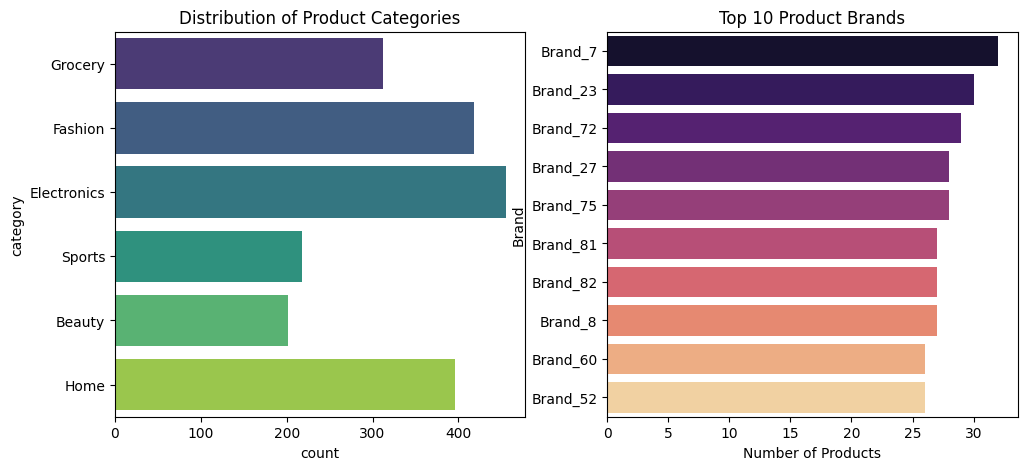

In [40]:
# 2. Visualizations for df4
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.countplot(y='category', data=df4, palette='viridis')
plt.title('Distribution of Product Categories')

plt.subplot(1, 3, 2)
top_brands = df4['brand'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, palette='magma')
plt.title('Top 10 Product Brands')
plt.xlabel('Number of Products')
plt.ylabel('Brand')


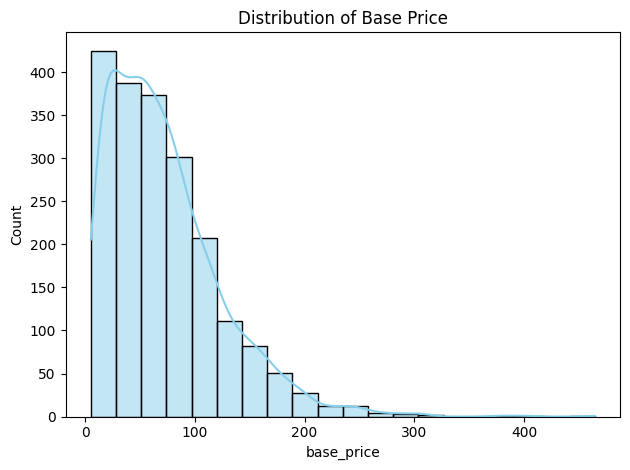

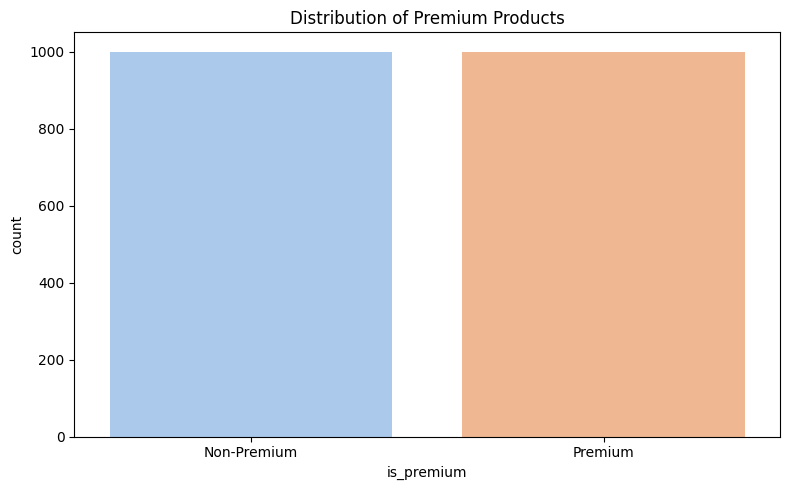

In [42]:
sns.histplot(df4['base_price'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Base Price')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='is_premium', data=df4, palette='pastel')
plt.title('Distribution of Premium Products')
plt.xticks([0, 1], ['Non-Premium', 'Premium'])
plt.tight_layout()
plt.show()

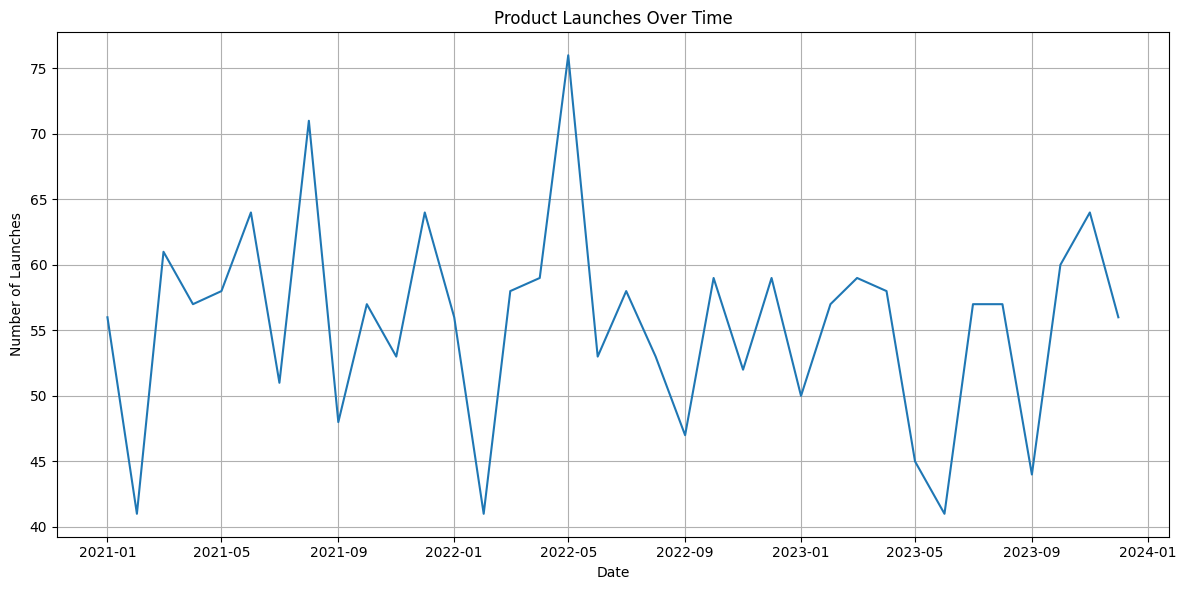

In [43]:
plt.figure(figsize=(12, 6))
df4['launch_year_month'] = df4['launch_date'].dt.to_period('M')
launches_over_time = df4['launch_year_month'].value_counts().sort_index()
launches_over_time.index = launches_over_time.index.to_timestamp()
sns.lineplot(x=launches_over_time.index, y=launches_over_time.values)
plt.title('Product Launches Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Launches')
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
# --- Data Cleaning and Visualization for df5 (transactions) ---
print("\n--- Cleaning and Visualizing df5 (transactions) ---")

# 1. Data Cleaning df5
print("\nChecking for missing values in df5:")
print(df5.isnull().sum())
print("\nChecking for duplicate rows in df5:")
print(df5.duplicated().sum())



--- Cleaning and Visualizing df5 (transactions) ---

Checking for missing values in df5:
transaction_id          0
timestamp               0
customer_id             0
product_id          10449
quantity                0
discount_applied        0
gross_revenue       10449
campaign_id             0
refund_flag             0
dtype: int64

Checking for duplicate rows in df5:
0


In [45]:
df5['timestamp'] = pd.to_datetime(df5['timestamp'])
# Handling missing product_id: potentially replace with a placeholder or drop rows. For now, let's keep them and acknowledge.
# For analysis requiring product_id, these would need more careful handling.
print("Converted 'timestamp' to datetime objects in df5.")

Converted 'timestamp' to datetime objects in df5.


Text(0.5, 1.0, 'Distribution of Transaction Quantity')

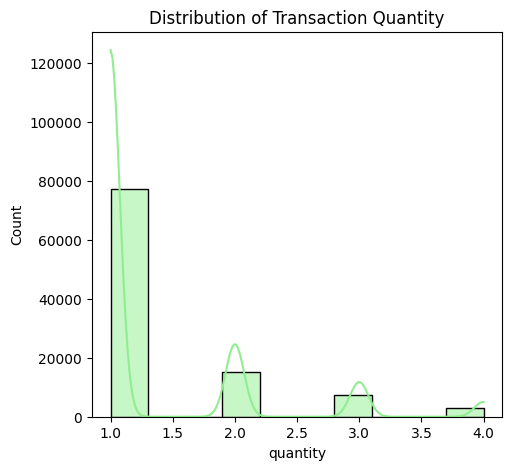

In [47]:
# 2. Visualizations for df5
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.histplot(df5['quantity'], bins=10, kde=True, color='lightgreen')
plt.title('Distribution of Transaction Quantity')


Text(0.5, 1.0, 'Distribution of Transaction Price')

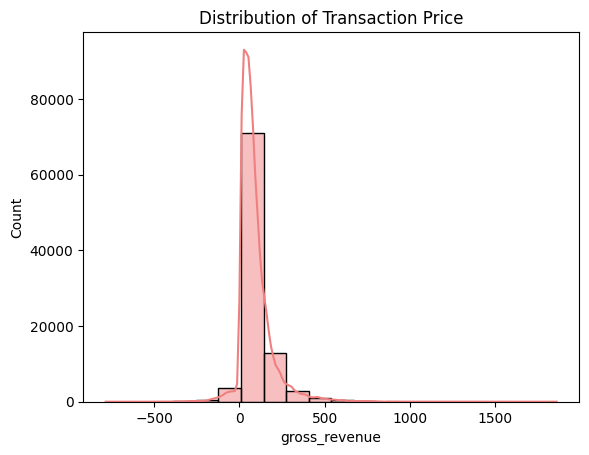

In [54]:
sns.histplot(df5['gross_revenue'], bins=20, kde=True, color='lightcoral')
plt.title('Distribution of Transaction Price')

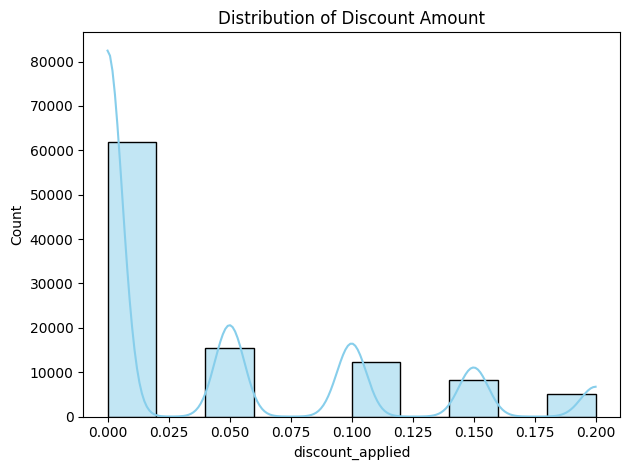

In [56]:
sns.histplot(df5['discount_applied'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Discount Amount')
plt.tight_layout()
plt.show()


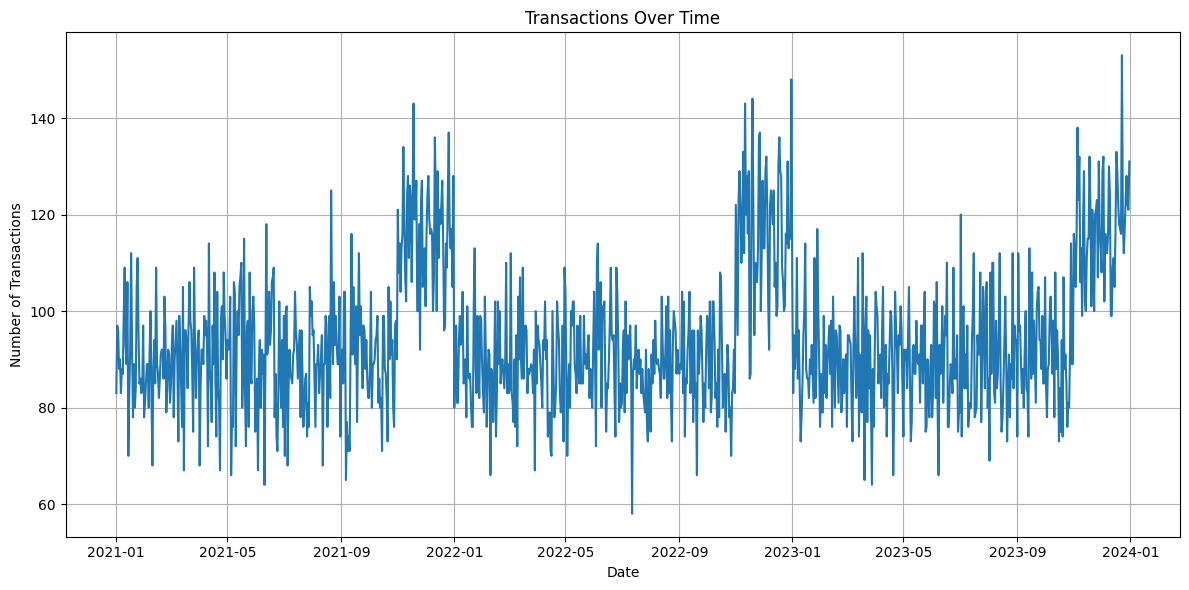

In [58]:
plt.figure(figsize=(12, 6))
df5['transaction_date'] = df5['timestamp'].dt.to_period('D')
transactions_over_time = df5['transaction_date'].value_counts().sort_index()
transactions_over_time.index = transactions_over_time.index.to_timestamp()
sns.lineplot(x=transactions_over_time.index, y=transactions_over_time.values)
plt.title('Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()
